# Painel de Análise e Validação de Performance

**Objetivo:** Este é o painel de controle central para analisar o desempenho dos modelos. Ele consolida a validação de performance, visualizações de viés e a explicabilidade (XAI) das previsões.

**Processo:**
1.  **Validação Histórica:** Carrega o log de previsões, busca os preços reais e calcula a performance, adicionando ao log os preços inicial/final e o retorno real.
2.  **Análise Visual:** Gera gráficos comparando a distribuição de previsões vs. resultados reais e matrizes de confusão, **um para cada horizonte**.
3.  **Explicabilidade:** Analisa a previsão mais recente para um horizonte específico, mostrando as **features mais importantes** que o modelo usou para tomar sua decisão.

In [2]:
# --- Célula de Instalação e Importação de Bibliotecas ---
!pip install -q pandas numpy yfinance scikit-learn seaborn matplotlib catboost

import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime, timedelta
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import os

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


In [ ]:
# --- Célula de Carregamento e Validação ---

LOG_FILE = 'log_previsoes_com_reais.csv'
RAW_LOG_FILE = 'log_previsoes.csv' =
DATA_FILE = 'aluminium_full_featured_retrained.csv'
MODELS_DIR = 'models/'
OUTPUT_VALIDATED_LOG = 'log_previsoes_com_reais.csv' 

# Tenta carregar o log de previsões
try:
    log_columns = pd.read_csv(RAW_LOG_FILE, nrows=0).columns
    date_cols_to_parse = ['data_base_previsao']
    if 'data_execucao' in log_columns: date_cols_to_parse.append('data_execucao')
    if 'data_execucao_simulada' in log_columns: date_cols_to_parse.append('data_execucao_simulada')
    
    df_log = pd.read_csv(RAW_LOG_FILE, parse_dates=date_cols_to_parse)
    print(f"{len(df_log)} previsões carregadas do log '{RAW_LOG_FILE}'.")

except FileNotFoundError:
    print(f"ERRO: Arquivo de log '{RAW_LOG_FILE}' não encontrado.")
    df_log = None

# Função para classificar o retorno real
def classify_real_return(x):
    if x > 0.10: return "Sobe muito"
    elif x > 0.03: return "Sobe"
    elif x >= -0.03: return "Na mesma"
    elif x > -0.10: return "Cai"
    else: return "Cai muito"

# Busca os preços históricos
if df_log is not None:
    start_date_prices = df_log['data_base_previsao'].min() - timedelta(days=5)
    end_date_prices = datetime.today() + timedelta(days=1)
    
    print(f"Buscando preços do alumínio de {start_date_prices.date()} até {end_date_prices.date()}...")
    prices_df = yf.download('ALI=F', start=start_date_prices, end=end_date_prices, progress=False)['Close'].reset_index()
    prices_df.columns = ['date', 'aluminum_price']
    prices_df['date'] = pd.to_datetime(prices_df['date'])
    print("Download de preços concluído.")

    # --- Lógica de Validação ---
    df_log['preco_inicial'] = None
    df_log['preco_final'] = None
    df_log['retorno_real'] = None
    df_log['classe_real'] = None

    for index, row in df_log.iterrows():
        data_base = row['data_base_previsao']
        horizonte = row['horizonte_dias']
        data_alvo = data_base + timedelta(days=horizonte)

        if data_alvo < datetime.now():
            preco_inicial_series = prices_df[prices_df['date'] == data_base]
            preco_final_series = prices_df[prices_df['date'] >= data_alvo].sort_values('date').iloc[0:1]

            if not preco_inicial_series.empty and not preco_final_series.empty:
                preco_inicial = preco_inicial_series['aluminum_price'].iloc[0]
                preco_final = preco_final_series['aluminum_price'].iloc[0]
                retorno_real = (preco_final - preco_inicial) / preco_inicial
                classe_real = classify_real_return(retorno_real)
                
                df_log.loc[index, 'preco_inicial'] = preco_inicial
                df_log.loc[index, 'preco_final'] = preco_final
                df_log.loc[index, 'retorno_real'] = retorno_real
                df_log.loc[index, 'classe_real'] = classe_real

    df_log.to_csv(OUTPUT_VALIDATED_LOG, index=False, float_format='%.4f')
    print(f"\nLog atualizado com preços e resultados reais salvo em '{OUTPUT_VALIDATED_LOG}'.")
    
    df_validado = df_log.dropna(subset=['classe_real']).copy()
    
    if not df_validado.empty:
        print(f"Total de {len(df_validado)} previsões foram validadas e serão usadas para a análise.")
        display(df_validado[['data_base_previsao', 'horizonte_dias', 'previsao_classe', 'classe_real', 'preco_inicial', 'preco_final', 'retorno_real']].tail())
    else:
        print("\nNenhuma previsão pôde ser validada ainda.")

64 previsões carregadas do log 'log_previsoes.csv'.
Buscando preços do alumínio de 2025-08-24 até 2025-09-17...


C:\Users\renan\AppData\Local\Temp\ipykernel_2596\4286338696.py:38: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices_df = yf.download('ALI=F', start=start_date_prices, end=end_date_prices, progress=False)['Close'].reset_index()


Download de preços concluído.

Log atualizado com preços e resultados reais salvo em 'log_previsoes_com_reais.csv'.
Total de 24 previsões foram validadas e serão usadas para a análise.


,data_base_previsao,horizonte_dias,previsao_classe,classe_real,preco_inicial,preco_final,retorno_real
41,2025-09-10,5,Cai muito,Na mesma,2518.25,2591.0,0.028889
44,2025-09-11,1,Na mesma,Na mesma,2587.75,2583.75,-0.001546
48,2025-09-12,1,Na mesma,Na mesma,2583.75,2591.0,0.002806
52,2025-09-12,1,Na mesma,Na mesma,2583.75,2591.0,0.002806
56,2025-09-12,1,Na mesma,Na mesma,2583.75,2591.0,0.002806



  Análise de Performance para Horizonte: 1 dia(s)


C:\Users\renan\AppData\Local\Temp\ipykernel_2596\2298938170.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_horizon, x='previsao_classe', order=all_classes_order, palette='viridis')
C:\Users\renan\AppData\Local\Temp\ipykernel_2596\2298938170.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_horizon, x='classe_real', order=all_classes_order, palette='plasma')


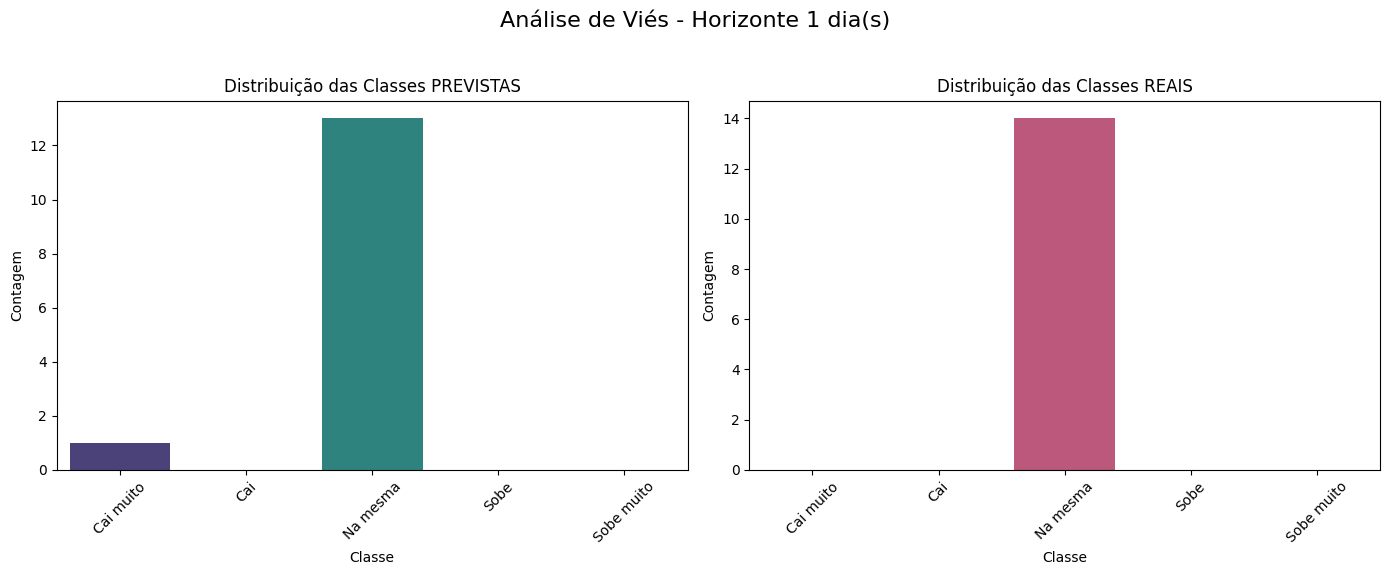


Relatório de Classificação:
              precision    recall  f1-score   support

   Cai muito       0.00      0.00      0.00         0
         Cai       0.00      0.00      0.00         0
    Na mesma       1.00      0.93      0.96        14
        Sobe       0.00      0.00      0.00         0
  Sobe muito       0.00      0.00      0.00         0

    accuracy                           0.93        14
   macro avg       0.20      0.19      0.19        14
weighted avg       1.00      0.93      0.96        14



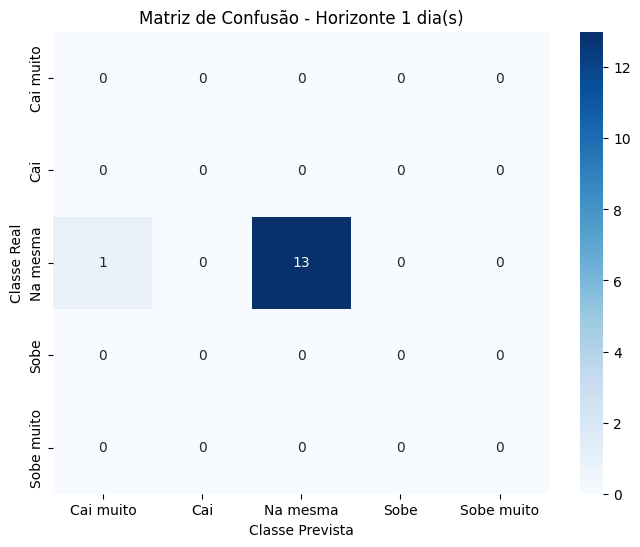


  Análise de Performance para Horizonte: 5 dia(s)


C:\Users\renan\AppData\Local\Temp\ipykernel_2596\2298938170.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_horizon, x='previsao_classe', order=all_classes_order, palette='viridis')
C:\Users\renan\AppData\Local\Temp\ipykernel_2596\2298938170.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_horizon, x='classe_real', order=all_classes_order, palette='plasma')


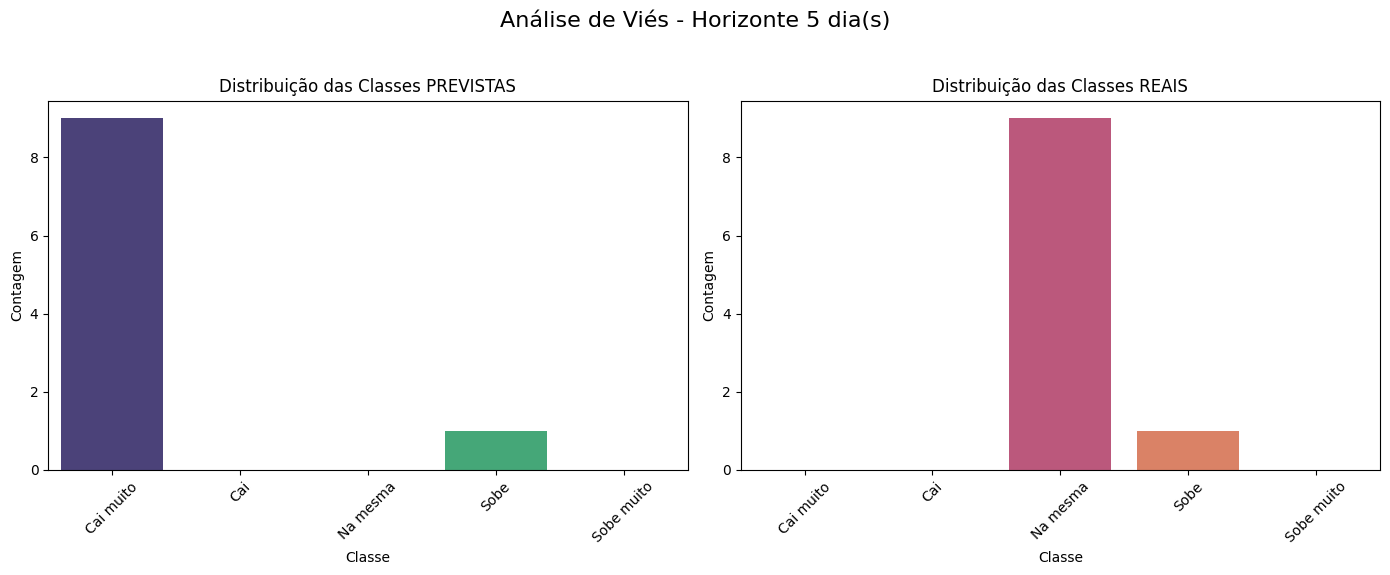


Relatório de Classificação:
              precision    recall  f1-score   support

   Cai muito       0.00      0.00      0.00       0.0
         Cai       0.00      0.00      0.00       0.0
    Na mesma       0.00      0.00      0.00       9.0
        Sobe       0.00      0.00      0.00       1.0
  Sobe muito       0.00      0.00      0.00       0.0

    accuracy                           0.00      10.0
   macro avg       0.00      0.00      0.00      10.0
weighted avg       0.00      0.00      0.00      10.0



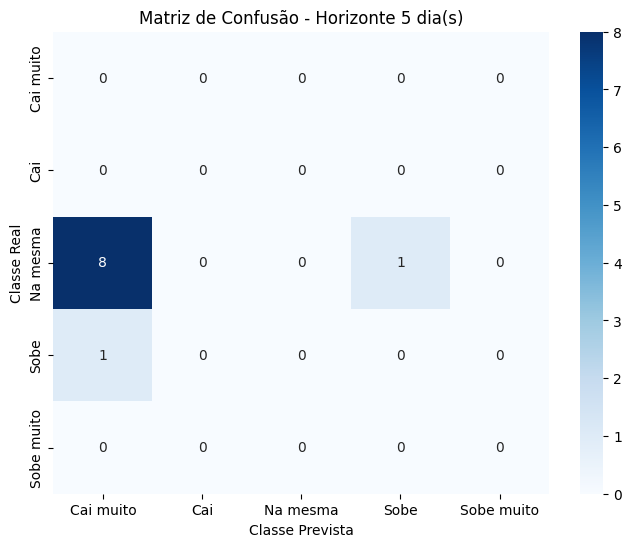

In [4]:
# --- Célula de Análise Visual da Performance Histórica ---

if 'df_validado' in locals() and not df_validado.empty:
    
    all_classes_order = ["Cai muito", "Cai", "Na mesma", "Sobe", "Sobe muito"]

    for h in sorted(df_validado['horizonte_dias'].unique()):
        
        df_horizon = df_validado[df_validado['horizonte_dias'] == h]
        
        print(f"\n========================================================")
        print(f"  Análise de Performance para Horizonte: {h} dia(s)")
        print(f"========================================================")
        
        # 1. Análise de Viés para este horizonte
        plt.figure(figsize=(14, 6))
        plt.suptitle(f'Análise de Viés - Horizonte {h} dia(s)', fontsize=16)
        
        plt.subplot(1, 2, 1)
        sns.countplot(data=df_horizon, x='previsao_classe', order=all_classes_order, palette='viridis')
        plt.title('Distribuição das Classes PREVISTAS')
        plt.xlabel('Classe')
        plt.ylabel('Contagem')
        plt.xticks(rotation=45)

        plt.subplot(1, 2, 2)
        sns.countplot(data=df_horizon, x='classe_real', order=all_classes_order, palette='plasma')
        plt.title('Distribuição das Classes REAIS')
        plt.xlabel('Classe')
        plt.ylabel('Contagem')
        plt.xticks(rotation=45)
        
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

        # 2. Relatório de Classificação e Matriz de Confusão
        y_true = df_horizon['classe_real']
        y_pred = df_horizon['previsao_classe']
        
        print("\nRelatório de Classificação:")
        print(classification_report(y_true, y_pred, labels=all_classes_order, zero_division=0))
        
        cm = confusion_matrix(y_true, y_pred, labels=all_classes_order)
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=all_classes_order, yticklabels=all_classes_order)
        plt.title(f'Matriz de Confusão - Horizonte {h} dia(s)')
        plt.ylabel('Classe Real')
        plt.xlabel('Classe Prevista')
        plt.show()

--- Análise de Importância e Justificativa para Horizonte: 5 dias ---

--- FEATURES MAIS IMPORTANTES (GERAL) ---
Estas são as features que o modelo mais considera ao tomar qualquer decisão:
                    feature  importance
488        alum_zscore_ma10    2.371087
490        alum_zscore_ma21    1.871342
254            eurusd_std10    1.407138
12                      xlb    1.403686
196                gas_std5    1.386288
348          hindalco_std21    1.368308
312             alcoa_std21    1.281239
128               tin_std10    1.223941
330  century_aluminum_std21    1.219932
290               xlb_std10    1.206858
294               xlb_std21    1.193819
232             usdcny_std5    1.184717
344          hindalco_std10    1.121217
110              zinc_std10    1.111328
258            eurusd_std21    1.003099


C:\Users\renan\AppData\Local\Temp\ipykernel_2596\2417277979.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=top_features, palette='rocket')


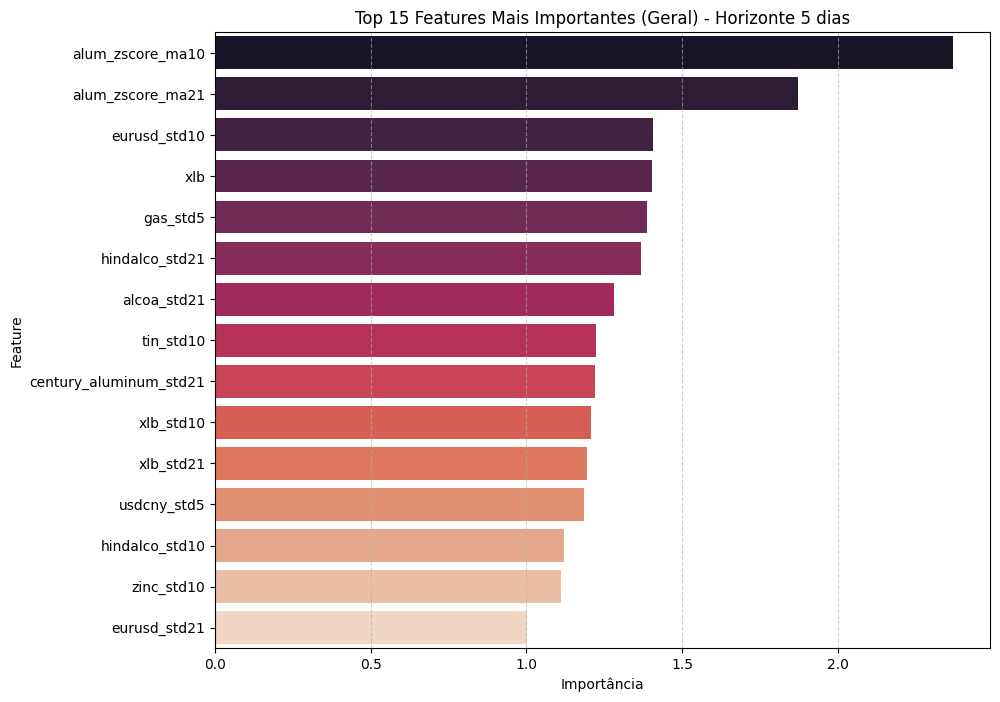


--- JUSTIFICATIVA DA PREVISÃO ---
Valores das features mais importantes nos dados de 2025-09-15 que levaram à previsão:


,Valor no Dia
alum_zscore_ma10,1.840826
alum_zscore_ma21,1.945725
eurusd_std10,9.769048
xlb,43.020000
gas_std5,0.002729
hindalco_std21,0.689207
alcoa_std21,0.022544
tin_std10,1.019390
century_aluminum_std21,0.868575
xlb_std10,0.644499



Valores em formato de texto:
                        Valor no Dia
alum_zscore_ma10            1.840826
alum_zscore_ma21            1.945725
eurusd_std10                9.769048
xlb                        43.020000
gas_std5                    0.002729
hindalco_std21              0.689207
alcoa_std21                 0.022544
tin_std10                   1.019390
century_aluminum_std21      0.868575
xlb_std10                   0.644499
xlb_std21                   0.844572
usdcny_std5                 0.056969
hindalco_std10              0.475027
zinc_std10                  0.033752
eurusd_std21               19.472729


In [6]:
# --- Célula de Análise de Explicabilidade e Justificativa da Última Previsão ---

# HORIZONTE PARA ANÁLISE (você pode mudar para 1, 5, 30, ou 90)
HORIZONTE_ANALISADO = 5
TOP_N_FEATURES = 15 # Quantas features investigar

print(f"--- Análise de Importância e Justificativa para Horizonte: {HORIZONTE_ANALISADO} dias ---")

try:
    # 1. CARREGAR OS DADOS E O MODELO
    df_features = pd.read_csv('aluminium_full_featured_retrained.csv', parse_dates=['date'])
    latest_data = df_features.sort_values('date', ascending=False).iloc[0:1]
    data_base_previsao = latest_data['date'].dt.date.iloc[0]
    
    model = joblib.load(os.path.join('models/', f'catboost_model_horizon_{HORIZONTE_ANALISADO}d_retrained.joblib'))
    
    # 2. OBTER AS FEATURES MAIS IMPORTANTES PARA O MODELO
    feature_importances = model.get_feature_importance()
    feature_names = model.feature_names_
    
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': feature_importances
    }).sort_values('importance', ascending=False)
    
    top_features = importance_df.head(TOP_N_FEATURES)
    
    # 3. PRINTAR E EXIBIR O GRÁFICO DE IMPORTÂNCIA GERAL
    print("\n--- FEATURES MAIS IMPORTANTES (GERAL) ---")
    print("Estas são as features que o modelo mais considera ao tomar qualquer decisão:")
    print(top_features.to_string()) # Printa a tabela completa
    
    plt.figure(figsize=(10, 8))
    sns.barplot(x='importance', y='feature', data=top_features, palette='rocket')
    plt.title(f'Top {TOP_N_FEATURES} Features Mais Importantes (Geral) - Horizonte {HORIZONTE_ANALISADO} dias')
    plt.xlabel('Importância')
    plt.ylabel('Feature')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.show()

    # 4. EXIBIR E PRINTAR OS VALORES DAS FEATURES IMPORTANTES NO DIA DA PREVISÃO
    print(f"\n--- JUSTIFICATIVA DA PREVISÃO ---")
    print(f"Valores das features mais importantes nos dados de {data_base_previsao} que levaram à previsão:")
    
    # Pega os valores das features mais importantes da última linha de dados
    latest_values = latest_data[top_features['feature'].tolist()].T
    latest_values.columns = ['Valor no Dia']
    
    display(latest_values) # Mostra a tabela formatada no notebook
    print("\nValores em formato de texto:")
    print(latest_values) # Printa a mesma tabela para o console/log

except Exception as e:
    print(f"Ocorreu um erro ao gerar a análise de importância: {e}")

 Tese do Modelo: O Preço do Alumínio Estava "Esticado"
A história que o seu modelo está contando é baseada em uma teoria de reversão à média. Vamos traduzir o que as features mais importantes significam:

alum_zscore_ma10 (Importância: 2.37 | Valor no Dia: 1.84)

Esta feature mede quão "longe" o preço atual do alumínio está da sua média dos últimos 10 dias, em unidades de desvio padrão.

O que o valor 1.84 significa: Significa que o preço do alumínio no dia da previsão estava 1.84 desvios padrão ACIMA da sua média de 10 dias. Em termos de mercado, isso é um sinal clássico de que o ativo está "sobrecomprado" ou "esticado". O preço subiu muito rápido em um curto período.

alum_zscore_ma21 (Importância: 1.87 | Valor no Dia: 1.95)

 A mesma lógica, mas em relação à média dos últimos 21 dias (aproximadamente um mês de pregões).

O que o valor 1.95 significa: O sinal aqui é ainda mais forte. O preço estava quase 2 desvios padrão ACIMA da sua média mensal.




O modelo olhou para esses dois indicadores, que são os mais importantes para ele, e concluiu que o preço do alumínio havia subido demais e muito rápido. Ele aprendeu com os dados de treinamento que, quando o preço fica tão "esticado" assim, a probabilidade de uma correção (uma queda) nos próximos 5 dias é muito alta. Por isso, ele fez a previsão agressiva de "Cai muito".

+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=

eurusd_std10 e eurusd_std21 (Volatilidade do Euro/Dólar): Valores altos aqui indicam alta volatilidade no mercado de moedas, o que pode ser um sinal de incerteza ou aversão ao risco no mercado global. Em cenários de incerteza, investidores tendem a vender ativos de risco como commodities, o que reforçaria a previsão de queda.

xlb (ETF do Setor de Materiais): O modelo aprendeu um padrão no comportamento deste ETF que, combinado com os outros sinais, aponta para uma queda.

gas_std5, hindalco_std21 (Volatilidade do Gás Natural e da Hindalco): Assim como a volatilidade do câmbio, a instabilidade em outros mercados relacionados (energia e outras empresas do setor) serve como um sinal de alerta para o modelo.

Resumo da Investigação